# Florence-2 Fashion Image Description Generator

Generate detailed descriptions for fashion images using Microsoft's Florence-2 model.

In [1]:
import os
import pandas as pd
from PIL import Image
from tqdm.notebook import tqdm
import torch
from transformers import AutoProcessor, AutoModelForCausalLM
import warnings
warnings.filterwarnings('ignore')

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU


In [2]:
# ============ CONFIGURATION ============
INPUT_FOLDER = r"C:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanManh\Fashion-Marketing-Automation-Solutions\images\original_images"
OUTPUT_FILE = "../input/image_descriptions.csv"
MODEL_NAME = "microsoft/Florence-2-base"
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}

In [3]:
# Load Model
print(f"Loading {MODEL_NAME}...")

processor = AutoProcessor.from_pretrained(MODEL_NAME, trust_remote_code=True)

# Use float32 to avoid dtype issues (slower but more stable)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
    torch_dtype=torch.float32  # Use float32 for stability
).to(device)

model.eval()
print("Model loaded!")

Loading microsoft/Florence-2-base...
Model loaded!


In [4]:
def generate_description(image_path, task="<MORE_DETAILED_CAPTION>"):
    """
    Generate description for an image.
    Tasks: <CAPTION>, <DETAILED_CAPTION>, <MORE_DETAILED_CAPTION>
    """
    try:
        image = Image.open(image_path).convert('RGB')
        inputs = processor(text=task, images=image, return_tensors="pt").to(device)
        
        with torch.no_grad():
            generated_ids = model.generate(
                input_ids=inputs["input_ids"],
                pixel_values=inputs["pixel_values"],
                max_new_tokens=512,
                num_beams=3,
                do_sample=False
            )
        
        text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
        parsed = processor.post_process_generation(text, task=task, image_size=(image.width, image.height))
        return parsed.get(task, str(parsed))
    except Exception as e:
        print(f"Error: {e}")
        return ""

print("Function ready!")

Function ready!


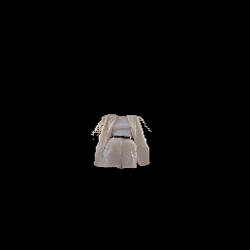

Generating...

Description:
The image is a black background with a white dress in the center. The dress is made of a light-colored fabric and has a high neckline and long sleeves. It has a belt at the waist with a silver buckle. The skirt of the dress is slightly flared and falls below the knees. The jacket has a loose fit and appears to be made of cotton or a similar material. The overall style of the outfit is elegant and sophisticated.


In [5]:
# Test with single image
test_image = "../images/segmented_images/outfit_1.png"

if os.path.exists(test_image):
    img = Image.open(test_image)
    display(img.resize((250, 250)))
    
    print("Generating...")
    desc = generate_description(test_image)
    print(f"\nDescription:\n{desc}")
else:
    print(f"Not found: {test_image}")

In [6]:
# Get image list
if os.path.exists(INPUT_FOLDER):
    image_files = [f for f in os.listdir(INPUT_FOLDER) if os.path.splitext(f)[1].lower() in IMAGE_EXTENSIONS]
    print(f"Found {len(image_files)} images")
    print(f"Sample: {image_files[:5]}")
else:
    print(f"Folder not found: {INPUT_FOLDER}")
    image_files = []

Found 822 images
Sample: ['1.jpg', '10.jpg', '100.jpg', '101.jpg', '102.jpg']


In [7]:
# Process all images
results = []

if image_files:
    print(f"Processing {len(image_files)} images...\n")
    
    for filename in tqdm(image_files):
        image_path = os.path.join(INPUT_FOLDER, filename)
        image_id = os.path.splitext(filename)[0]
        description = generate_description(image_path)
        
        results.append({
            'image_id': image_id,
            'filename': filename,
            'description': description
        })
    
    print(f"\nDone! Processed {len(results)} images")

Processing 822 images...



  0%|          | 0/822 [00:00<?, ?it/s]


Done! Processed 822 images


In [10]:
# Save results
if results:
    df = pd.DataFrame(results)
    
    output_dir = os.path.dirname(OUTPUT_FILE)
    if output_dir and not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    df.to_csv(OUTPUT_FILE, index=False, encoding='utf-8')
    print(f"Saved to: {OUTPUT_FILE}")
df.head()

Saved to: ../input/image_descriptions.csv


,image_id,filename,description
0,1,1.jpg,The image shows a young woman standing in the ...
1,10,10.jpg,The image shows a woman standing in front of a...
2,100,100.jpg,The image shows a woman standing in a subway s...
3,101,101.jpg,The image shows a young woman standing in a ha...
4,102,102.jpg,The image shows a young woman standing in a ro...


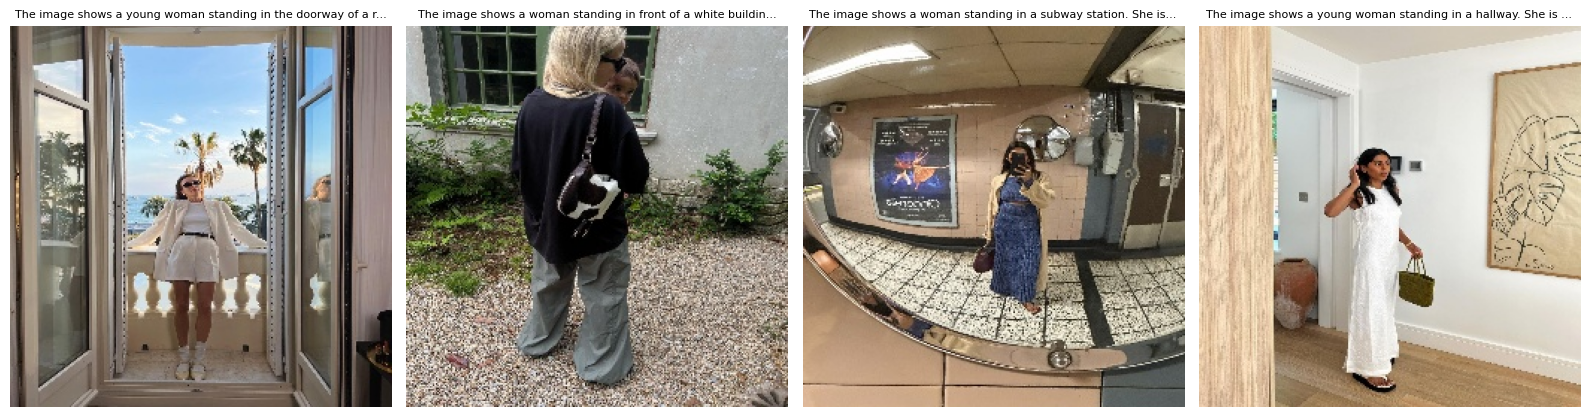

In [9]:
# Visualize results
import matplotlib.pyplot as plt

if results:
    n = min(4, len(results))
    fig, axes = plt.subplots(1, n, figsize=(4*n, 5))
    if n == 1: axes = [axes]
    
    for ax, row in zip(axes, results[:n]):
        img = Image.open(os.path.join(INPUT_FOLDER, row['filename']))
        ax.imshow(img)
        ax.set_title(f"{row['description'][:60]}...", fontsize=8, wrap=True)
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()